# Predicting whether a customer will default on a loan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# Generate some synthetic data
np.random.seed(42)

n = 1000

age = np.random.randint(low=20, high=70, size=n)
income = np.random.normal(loc=70000, scale=20000, size=n).clip(20000, 150000)
debt_ratio = np.random.uniform(0.05, 0.6, size=n)
credit_score = np.random.normal(680, 80, n).clip(300, 850)

# Simulate the target variable
# More likely if low income, high debt, low credit_score
prob_default = (0.3*(income<50000) +
                0.4*(debt_ratio>0.4) +
                0.3*(credit_score<600) +
                np.random.normal(0, 0.1, n))
loan_default = (prob_default>0.5).astype(int)

# Convert it into a dataframe
df = pd.DataFrame({
    "age": age,
    "income": income,
    "credit_score": credit_score,
    "loan_default": loan_default
})
df.head()

,age,income,credit_score,loan_default
0,58,57658.191834,718.029283,0
1,48,44823.159169,668.292612,1
2,34,93776.020153,606.040223,1
3,62,69173.831388,706.413347,0
4,27,73479.326583,796.536796,0


C:\Users\muham\AppData\Local\Temp\ipykernel_15060\2724296746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="loan_default", palette="coolwarm")


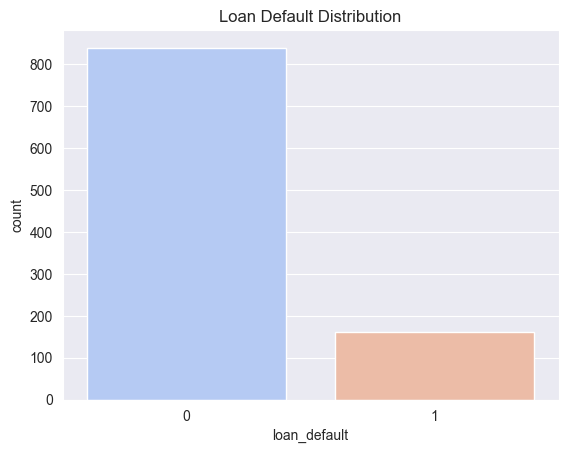

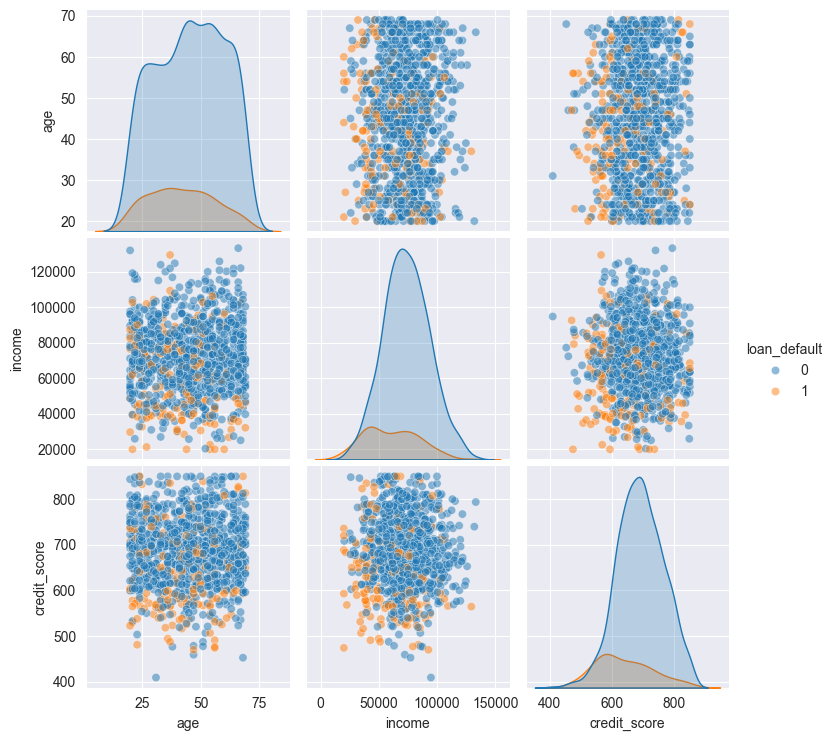

In [3]:
# Explore the data
sns.countplot(data=df, x="loan_default", palette="coolwarm")
plt.title("Loan Default Distribution")
sns.pairplot(df, hue='loan_default', diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

In [4]:
# Prepare data for KNN

# Split the data
X = df.drop(columns=["loan_default"])
y = df["loan_default"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Train KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.845


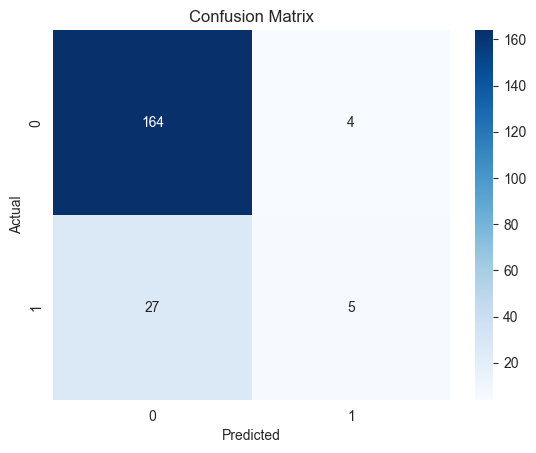

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

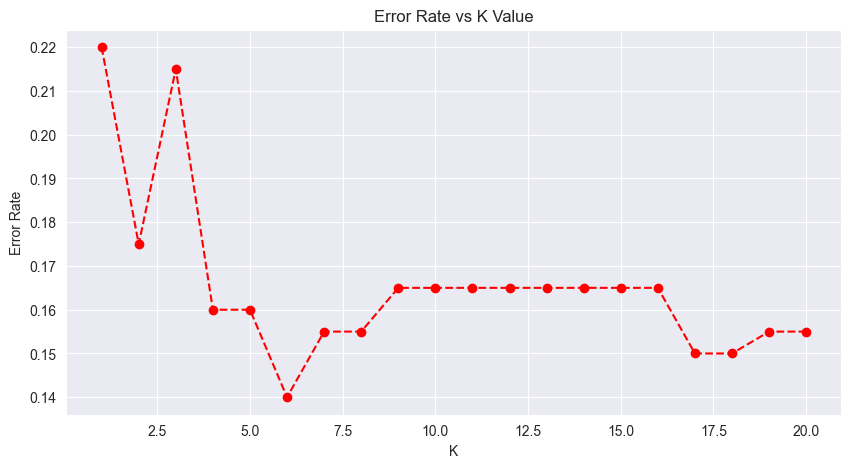

In [9]:
# Tune the number of KNeighbors
error_rates = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred_k = model.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred_k))

plt.figure(figsize=(10,5))
plt.plot(range(1,21), error_rates, marker='o', linestyle='dashed', color='red')
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()

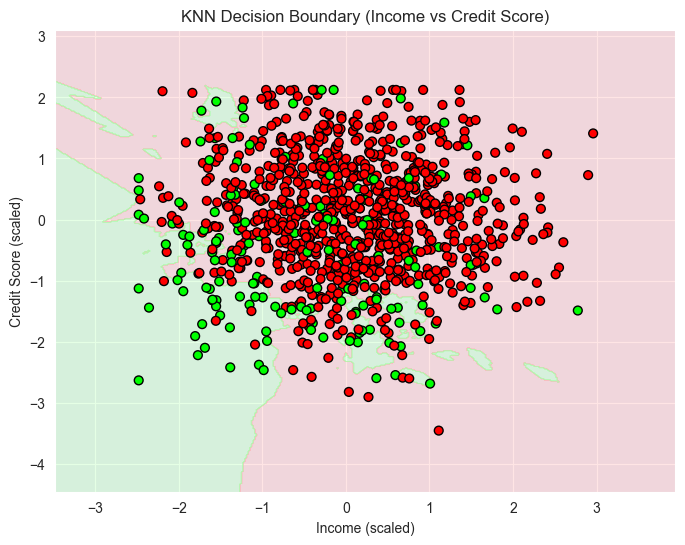

In [10]:
# Visualize Decision Regions
from matplotlib.colors import ListedColormap

# Select two features
X_vis = df[['income', 'credit_score']].values
y_vis = df['loan_default']

X_vis = StandardScaler().fit_transform(X_vis)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_vis, y_vis)
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=40)
plt.xlabel('Income (scaled)')
plt.ylabel('Credit Score (scaled)')
plt.title("KNN Decision Boundary (Income vs Credit Score)")
plt.show()